# Lab 17 — Autoregressive Language Models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-17-autoregressive-language-models.ipynb)

This lab accompanies **Chapter 17: Autoregressive Language Models** in *The Mathematics of Natural Language Processing*.

Autoregressive language modeling is the probability engine behind decoder-only large language models.  The central idea is simple:

$$
p(w_{1:T}) = \prod_{t=1}^{T} p(w_t \mid w_{<t}).
$$

Instead of assigning one probability to a whole sentence at once, the model predicts one token at a time.  During training, the model sees true prefixes from the data.  During generation, the model conditions on its own previous outputs.

This notebook is designed for independent study.  It introduces all background ideas before programming.

## Learning goals

By the end of this lab, you should be able to:

1. explain the autoregressive chain rule for token sequences;
2. construct next-token training pairs from text;
3. compute log-probability, average negative log-likelihood, and perplexity;
4. implement softmax, temperature scaling, top-$k$ sampling, and nucleus sampling;
5. compare greedy decoding, random sampling, filtered sampling, and beam search;
6. explain why decoder-only Transformers require causal masks;
7. train a tiny next-token model from scratch using cross-entropy gradients.

## 1. Mathematical background: from sequence probability to next-token prediction

Let $V$ be a finite vocabulary.  A token sequence is

$$
w_{1:T} = (w_1,w_2,\ldots,w_T).
$$

The chain rule of probability gives

$$
p(w_{1:T})
= p(w_1) p(w_2 \mid w_1) p(w_3 \mid w_1,w_2) \cdots p(w_T \mid w_{1:T-1}).
$$

Equivalently,

$$
p(w_{1:T}) = \prod_{t=1}^{T} p(w_t \mid w_{<t}).
$$

This factorization is exact.  An autoregressive language model estimates each conditional distribution

$$
p_\theta(\cdot \mid w_{<t}).
$$

For a modern neural model, the output is usually a vector of logits $z \in R^d$, one score for each vocabulary token.  The softmax function turns logits into probabilities:

$$
\operatorname{softmax}(z)_j
= \frac{\exp(z_j)}{\sum_{\ell=1}^{d}\exp(z_\ell)}.
$$

Training uses the negative log-probability of the observed next token:

$$
\ell_t = -\log p_\theta(w_t \mid w_{<t}).
$$

## 2. Setup

We use only standard scientific Python libraries available in Google Colab.  The corpus is intentionally small so that every probability table is inspectable.

In [1]:
import math
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(2026)

## 3. A small corpus

A real language model trains on billions or trillions of tokens.  In this lab, we use a tiny corpus of mathematics and NLP sentences.  The point is not to build a powerful model.  The point is to make every step of autoregressive modeling visible.

In [2]:
corpus = [
    "math models learn from data",
    "language models predict the next token",
    "probability models assign likelihood to text",
    "attention models use context to predict tokens",
    "transformers use causal masks for generation",
    "students study probability linear algebra and optimization",
    "vectors represent documents and words",
    "retrieval systems compare queries and documents",
    "language generation samples one token at a time",
    "neural models map prefixes to logits",
    "data and models guide mathematical reasoning",
    "proofs explain why algorithms work",
    "optimization trains neural models from examples",
    "causal masks prevent future information leakage",
    "students use probability to evaluate models",
]

for i, sent in enumerate(corpus[:5], start=1):
    print(f"{i:2d}. {sent}")
print(f"\nNumber of sentences: {len(corpus)}")

 1. math models learn from data
 2. language models predict the next token
 3. probability models assign likelihood to text
 4. attention models use context to predict tokens
 5. transformers use causal masks for generation

Number of sentences: 15


## 4. Tokenization and vocabulary

We use a simple word tokenizer:

- convert text to lowercase;
- extract alphabetic words;
- add `<bos>` at the beginning of each sentence;
- add `<eos>` at the end of each sentence.

`<bos>` means **beginning of sequence**.  `<eos>` means **end of sequence**.

In [3]:
def tokenize(text):
    # Simple tokenizer for this educational lab.
    return re.findall(r"[a-z]+", text.lower())

def encode_sentence(text):
    return ["<bos>"] + tokenize(text) + ["<eos>"]

tokenized = [encode_sentence(s) for s in corpus]

all_tokens = [tok for sent in tokenized for tok in sent]
counts = Counter(all_tokens)

special_tokens = ["<bos>", "<eos>", "<unk>"]
content_tokens = sorted([w for w in counts if w not in {"<bos>", "<eos>"}])
vocab = special_tokens + content_tokens
idx = {w: i for i, w in enumerate(vocab)}
inv_vocab = {i: w for w, i in idx.items()}

print("Vocabulary size:", len(vocab))
print("First 20 vocabulary items:", vocab[:20])
print("\nTokenized first sentence:")
print(tokenized[0])

Vocabulary size: 65
First 20 vocabulary items: ['<bos>', '<eos>', '<unk>', 'a', 'algebra', 'algorithms', 'and', 'assign', 'at', 'attention', 'causal', 'compare', 'context', 'data', 'documents', 'evaluate', 'examples', 'explain', 'for', 'from']

Tokenized first sentence:
['<bos>', 'math', 'models', 'learn', 'from', 'data', '<eos>']


### Checkpoint question

Why do we include `<eos>`?  Because generation must know when to stop.  Without an end token, a generator would need an artificial stopping rule unrelated to the learned sequence distribution.

## 5. Teacher forcing: build next-token training pairs

During training, an autoregressive model receives true prefixes from the training text.  For example,

```text
<bos> language models predict the next token <eos>
```

gives pairs such as:

```text
prefix: <bos> language models     target: predict
prefix: <bos> language models predict the next     target: token
```

A full Transformer can use the entire prefix.  A bigram model uses only the immediately previous token.  We start with a bigram model because its probabilities fit in a matrix.

In [4]:
training_rows = []
for sent_id, tokens in enumerate(tokenized):
    for t in range(1, len(tokens)):
        prefix = tokens[:t]
        prev_token = tokens[t - 1]
        target = tokens[t]
        training_rows.append({
            "sentence_id": sent_id,
            "prefix": " ".join(prefix),
            "bigram_context": prev_token,
            "target": target,
        })

pairs_df = pd.DataFrame(training_rows)
pairs_df.head(12)

,sentence_id,prefix,bigram_context,target
0,0,<bos>,<bos>,math
1,0,<bos> math,math,models
2,0,<bos> math models,models,learn
3,0,<bos> math models learn,learn,from
4,0,<bos> math models learn from,from,data
5,0,<bos> math models learn from data,data,<eos>
6,1,<bos>,<bos>,language
7,1,<bos> language,language,models
8,1,<bos> language models,models,predict
9,1,<bos> language models predict,predict,the


## 6. Bigram autoregressive model

The bigram approximation is

$$
p(w_t \mid w_{<t}) \approx p(w_t \mid w_{t-1}).
$$

This is not as powerful as a Transformer, but it is a clean autoregressive language model.  It defines a sequence probability by

$$
p(w_{1:T}) \approx \prod_{t=1}^{T} p(w_t \mid w_{t-1}).
$$

We estimate conditional probabilities from counts.  Let $C_{ij}$ be the number of times token $j$ follows token $i$.  With add-$\alpha$ smoothing,

$$
\widehat p(j\mid i)
= \frac{C_{ij}+\alpha}{\sum_{r=1}^{d} C_{ir}+\alpha d}.
$$

In [5]:
V = len(vocab)
C = np.zeros((V, V), dtype=float)

for tokens in tokenized:
    for a, b in zip(tokens[:-1], tokens[1:]):
        C[idx[a], idx[b]] += 1

def bigram_prob_matrix(alpha=0.1):
    # Return smoothed bigram transition matrix P[next | previous].
    numerator = C + alpha
    denominator = numerator.sum(axis=1, keepdims=True)
    return numerator / denominator

P = bigram_prob_matrix(alpha=0.1)
print("C shape:", C.shape)
print("P shape:", P.shape)
print("Every row sums to 1:", np.allclose(P.sum(axis=1), 1.0))

C shape: (65, 65)
P shape: (65, 65)
Every row sums to 1: True


In [6]:
def show_next_token_distribution(context_token, P, top_n=10):
    row = P[idx.get(context_token, idx["<unk>"])]
    order = np.argsort(row)[::-1][:top_n]
    return pd.DataFrame({
        "next_token": [inv_vocab[i] for i in order],
        "probability": row[order],
        "count": C[idx.get(context_token, idx["<unk>"]), order],
    })

show_next_token_distribution("models", P, top_n=12)

,next_token,probability,count
0,use,0.075862,1.0
1,guide,0.075862,1.0
2,predict,0.075862,1.0
3,<eos>,0.075862,1.0
4,assign,0.075862,1.0
5,learn,0.075862,1.0
6,from,0.075862,1.0
7,map,0.075862,1.0
8,work,0.006897,0.0
9,to,0.006897,0.0


## 7. Log-probability, average NLL, and perplexity

Products of many probabilities are numerically tiny, so language models usually work with log-probabilities:

$$
\log p(w_{1:T}) = \sum_{t=1}^{T} \log p(w_t \mid w_{<t}).
$$

The average negative log-likelihood per predicted token is

$$
\operatorname{NLL}_{\text{avg}}
= -\frac{1}{T}\sum_{t=1}^{T} \log p(w_t \mid w_{<t}).
$$

Perplexity is

$$
\operatorname{PPL} = \exp(\operatorname{NLL}_{\text{avg}}).
$$

A useful interpretation: perplexity is the effective average number of plausible next-token choices.

In [7]:
def sequence_log_probability(tokens, P):
    # Log-probability of a tokenized sentence that already includes <bos> and <eos>.
    logp = 0.0
    for a, b in zip(tokens[:-1], tokens[1:]):
        i = idx.get(a, idx["<unk>"])
        j = idx.get(b, idx["<unk>"])
        logp += math.log(P[i, j])
    return logp

def corpus_metrics(tokenized_sentences, P):
    total_logp = 0.0
    total_predictions = 0
    rows = []
    for sent in tokenized_sentences:
        logp = sequence_log_probability(sent, P)
        n_pred = len(sent) - 1
        total_logp += logp
        total_predictions += n_pred
        rows.append({
            "sentence": " ".join(sent),
            "predicted_tokens": n_pred,
            "log_probability": logp,
            "average_nll": -logp / n_pred,
            "perplexity": math.exp(-logp / n_pred),
        })
    avg_nll = -total_logp / total_predictions
    ppl = math.exp(avg_nll)
    return pd.DataFrame(rows), avg_nll, ppl

sentence_metrics, avg_nll, ppl = corpus_metrics(tokenized, P)
print(f"Corpus average NLL: {avg_nll:.4f} nats/token")
print(f"Corpus perplexity:  {ppl:.4f}")
sentence_metrics.head(6)

Corpus average NLL: 2.1367 nats/token
Corpus perplexity:  8.4713


,sentence,predicted_tokens,log_probability,average_nll,perplexity
0,<bos> math models learn from data <eos>,6,-13.480279,2.246713,9.456602
1,<bos> language models predict the next token <...,7,-14.878408,2.125487,8.376975
2,<bos> probability models assign likelihood to ...,7,-15.722406,2.246058,9.450409
3,<bos> attention models use context to predict ...,8,-17.767162,2.220895,9.215578
4,<bos> transformers use causal masks for genera...,7,-14.455551,2.065079,7.885918
5,<bos> students study probability linear algebr...,8,-16.586453,2.073307,7.951071


### Experiment: smoothing changes confidence

A smaller smoothing parameter makes the model more confident about observed transitions.  A larger smoothing parameter spreads probability mass to unseen transitions.

In [8]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]
rows = []
for alpha in alphas:
    P_alpha = bigram_prob_matrix(alpha=alpha)
    _, avg_nll_alpha, ppl_alpha = corpus_metrics(tokenized, P_alpha)
    rows.append({"alpha": alpha, "average_nll": avg_nll_alpha, "perplexity": ppl_alpha})

smoothing_df = pd.DataFrame(rows)
smoothing_df

,alpha,average_nll,perplexity
0,0.001,0.848258,2.335575
1,0.010,1.112688,3.042526
2,0.100,2.136689,8.471345
3,0.500,3.147677,23.281908
4,1.000,3.509186,33.421059
5,2.000,3.777459,43.704831


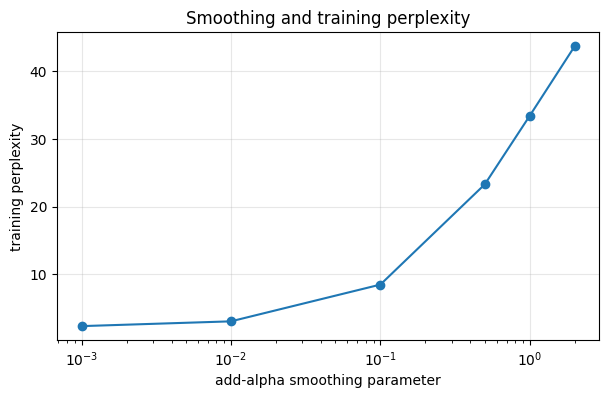

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(smoothing_df["alpha"], smoothing_df["perplexity"], marker="o")
plt.xscale("log")
plt.xlabel("add-alpha smoothing parameter")
plt.ylabel("training perplexity")
plt.title("Smoothing and training perplexity")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Softmax and temperature

Neural language models usually produce logits.  Temperature modifies the logits before softmax:

$$
p_j(\tau) = \frac{\exp(z_j/\tau)}{\sum_\ell \exp(z_\ell/\tau)}.
$$

- Small $\tau$ makes the distribution sharper.
- Large $\tau$ makes the distribution flatter.
- Temperature does not change the order of logits when there is a unique largest logit.

In [10]:
def softmax(logits, temperature=1.0):
    logits = np.asarray(logits, dtype=float) / temperature
    shifted = logits - np.max(logits)
    exps = np.exp(shifted)
    return exps / exps.sum()

def entropy(probs):
    probs = np.asarray(probs, dtype=float)
    positive = probs[probs > 0]
    return float(-np.sum(positive * np.log(positive)))

example_tokens = np.array(["math", "models", "learn", "data", "language", "proof"])
example_logits = np.array([2.5, 2.0, 1.2, 0.6, 0.1, -0.8])

rows = []
for tau in [0.35, 0.7, 1.0, 1.5, 3.0]:
    probs = softmax(example_logits, temperature=tau)
    rows.append({
        "temperature": tau,
        "entropy": entropy(probs),
        "exp_entropy": math.exp(entropy(probs)),
        "greedy_token": example_tokens[np.argmax(probs)],
    })

temperature_df = pd.DataFrame(rows)
temperature_df

,temperature,entropy,exp_entropy,greedy_token
0,0.35,0.604684,1.830674,math
1,0.70,1.116401,3.053843,math
2,1.00,1.362535,3.906083,math
3,1.50,1.563808,4.776976,math
4,3.00,1.726742,5.622308,math


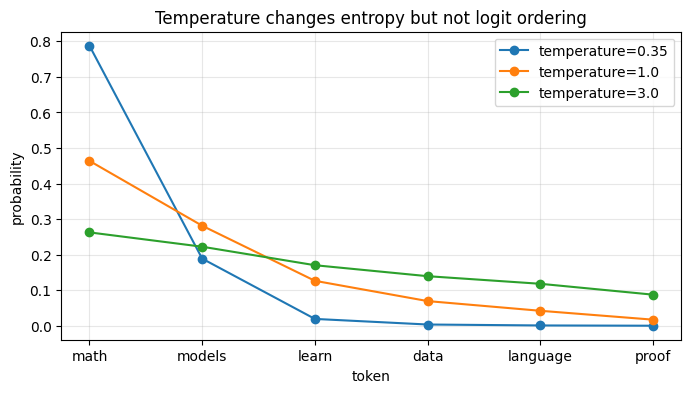

In [11]:
plt.figure(figsize=(8, 4))
for tau in [0.35, 1.0, 3.0]:
    probs = softmax(example_logits, temperature=tau)
    plt.plot(example_tokens, probs, marker="o", label=f"temperature={tau}")
plt.xlabel("token")
plt.ylabel("probability")
plt.title("Temperature changes entropy but not logit ordering")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Decoding rules

Generation repeats:

1. compute a next-token distribution;
2. choose a token;
3. append that token to the context;
4. repeat.

We implement four decoding styles:

- **greedy decoding:** always choose the largest-probability token;
- **temperature sampling:** sample from softmax logits divided by temperature;
- **top-$k$ sampling:** keep only the $k$ most likely tokens, then renormalize;
- **nucleus sampling:** keep the smallest set of tokens whose cumulative probability is at least $p_0$.

In [12]:
def top_k_filter(probs, k):
    probs = np.asarray(probs, dtype=float)
    if k is None or k >= len(probs):
        return probs / probs.sum()
    if k <= 0:
        raise ValueError("k must be positive")
    keep = np.argsort(probs)[::-1][:k]
    q = np.zeros_like(probs)
    q[keep] = probs[keep]
    return q / q.sum()

def top_p_filter(probs, p_threshold):
    probs = np.asarray(probs, dtype=float)
    if p_threshold is None or p_threshold >= 1.0:
        return probs / probs.sum()
    if p_threshold <= 0:
        raise ValueError("p_threshold must be positive")
    order = np.argsort(probs)[::-1]
    cumulative = np.cumsum(probs[order])
    m = int(np.searchsorted(cumulative, p_threshold, side="left")) + 1
    keep = order[:m]
    q = np.zeros_like(probs)
    q[keep] = probs[keep]
    return q / q.sum()

base_probs = softmax(example_logits)
filtered_df = pd.DataFrame({
    "token": example_tokens,
    "base": base_probs,
    "top_k_3": top_k_filter(base_probs, 3),
    "top_p_080": top_p_filter(base_probs, 0.80),
})
filtered_df

,token,base,top_k_3,top_p_080
0,math,0.463772,0.532180,0.532180
1,models,0.281292,0.322784,0.322784
2,learn,0.126393,0.145036,0.145036
3,data,0.069366,0.000000,0.000000
4,language,0.042072,0.000000,0.000000
5,proof,0.017105,0.000000,0.000000


Notice that top-$k$ fixes the number of allowed tokens, while top-$p$ fixes a probability-mass threshold.  The nucleus size can change from one context to another.

## 10. Text generation from the bigram model

A bigram model only conditions on the most recent token.  Still, it is a valid autoregressive generator:

$$
W_t \sim p(\cdot \mid W_{t-1}).
$$

To connect this with neural decoding, we convert the bigram probabilities into logits using $\log p$ and then apply temperature and filtering.

In [13]:
def next_probs_from_bigram(context_token, temperature=1.0, top_k=None, top_p=None):
    i = idx.get(context_token, idx["<unk>"])
    logits = np.log(P[i] + 1e-12)
    probs = softmax(logits, temperature=temperature)
    probs = top_k_filter(probs, top_k) if top_k is not None else probs
    probs = top_p_filter(probs, top_p) if top_p is not None else probs
    return probs

def generate_bigram(strategy="sample", temperature=1.0, top_k=None, top_p=None, max_new_tokens=20, seed=None):
    local_rng = np.random.default_rng(seed) if seed is not None else rng
    tokens = ["<bos>"]
    logp = 0.0
    for _ in range(max_new_tokens):
        context = tokens[-1]
        probs = next_probs_from_bigram(context, temperature=temperature, top_k=top_k, top_p=top_p)
        if strategy == "greedy":
            j = int(np.argmax(probs))
        elif strategy == "sample":
            j = int(local_rng.choice(np.arange(V), p=probs))
        else:
            raise ValueError("strategy must be 'greedy' or 'sample'")
        next_token = inv_vocab[j]
        tokens.append(next_token)
        logp += math.log(max(P[idx.get(context, idx["<unk>"]), j], 1e-12))
        if next_token == "<eos>":
            break
    return tokens, logp

def clean_generated(tokens):
    return " ".join([t for t in tokens if t not in {"<bos>", "<eos>"}])

settings = [
    ("greedy", {"strategy": "greedy", "temperature": 1.0}),
    ("temperature 0.7", {"strategy": "sample", "temperature": 0.7}),
    ("temperature 1.5", {"strategy": "sample", "temperature": 1.5}),
    ("top-k k=4", {"strategy": "sample", "temperature": 1.0, "top_k": 4}),
    ("top-p p=0.85", {"strategy": "sample", "temperature": 1.0, "top_p": 0.85}),
]

for name, kwargs in settings:
    print(f"\n{name}")
    for r in range(3):
        toks, score = generate_bigram(**kwargs, seed=1000 + 17*r)
        print("  ", clean_generated(toks))


greedy
   language generation
   language generation
   language generation

temperature 0.7
   optimization reasoning documents
   transformers use use math and models map prefixes logits
   vectors evaluate assign tokens study data

temperature 1.5
   one prevent linear causal masks data context systems models to text data and words probability generation causal optimization proofs trains
   transformers token words one algebra language next math generation assign future tokens systems for systems mathematical reasoning
   why assign algorithms words time algorithms and context neural prevent trains vectors future to at reasoning why context tokens for

top-k k=4
   students use context to predict the next token at words vectors represent documents work
   transformers why work
   transformers use causal words vectors represent documents

top-p p=0.85
   probability probability models from map information leakage students study token study learn from words proofs for generation retr

### Interpretation

The generator often sounds fragmentary because the corpus is tiny and the model only sees one previous token.  This is a feature, not a bug: it makes visible why longer-context models are needed.

## 11. Diversity and repetition diagnostics

Open-ended generation is not judged only by likelihood.  We can also inspect simple diversity statistics.

For a set of generated samples, define:

$$
\operatorname{distinct\text{-}1} = \frac{\#\{\text{unique generated tokens}\}}{\#\{\text{generated tokens}\}}.
$$

A larger value means more lexical variety.  It does not automatically mean better text.

In [14]:
def generation_diagnostics(kwargs, n_samples=100):
    all_content_tokens = []
    lengths = []
    ended = 0
    samples = []
    for s in range(n_samples):
        toks, _ = generate_bigram(**kwargs, seed=10_000 + s)
        content = [t for t in toks if t not in {"<bos>", "<eos>"}]
        all_content_tokens.extend(content)
        lengths.append(len(content))
        ended += int(toks[-1] == "<eos>")
        if s < 3:
            samples.append(clean_generated(toks))
    if len(all_content_tokens) == 0:
        distinct_1 = 0.0
    else:
        distinct_1 = len(set(all_content_tokens)) / len(all_content_tokens)
    return {
        "avg_length": float(np.mean(lengths)),
        "ended_fraction": ended / n_samples,
        "distinct_1": distinct_1,
        "example_1": samples[0],
        "example_2": samples[1],
        "example_3": samples[2],
    }

diag_rows = []
for name, kwargs in settings:
    diag = generation_diagnostics(kwargs, n_samples=100)
    diag["decoding"] = name
    diag_rows.append(diag)

diag_df = pd.DataFrame(diag_rows)[["decoding", "avg_length", "ended_fraction", "distinct_1", "example_1", "example_2", "example_3"]]
diag_df

,decoding,avg_length,ended_fraction,distinct_1,example_1,example_2,example_3
0,greedy,2.00,1.00,0.010000,language generation,language generation,language generation
1,temperature 0.7,9.69,0.84,0.065015,optimization information leakage,retrieval systems compare models from data,proofs explain text proofs time <unk> language...
2,temperature 1.5,13.97,0.51,0.045097,next logits neural evaluate compare study line...,retrieval proofs from for future for,proofs explain one proofs tokens from from stu...
3,top-k k=4,5.69,1.00,0.082601,students study probability linear algebra vect...,students use context to logits,students study probability linear algebra words
4,top-p p=0.85,13.40,0.65,0.045522,probability models math language generation st...,students study math models guide linear algebr...,retrieval likelihood represent compare queries...


## 12. Beam search

Beam search is an approximate search procedure.  It keeps the best $B$ partial sequences at each step.  The score of a candidate sequence is usually the sum of log-probabilities:

$$
s(w_{1:T}) = \sum_{t=1}^{T} \log p(w_t \mid w_{<t}).
$$

Because log-probabilities are usually negative, raw log-probability tends to prefer shorter sequences.  A length-normalized score is often used:

$$
s_\alpha(w_{1:T}) = \frac{s(w_{1:T})}{T^\alpha}.
$$

In [15]:
def beam_search_bigram(beam_width=3, max_new_tokens=8, alpha=0.6):
    beam = [(["<bos>"], 0.0)]

    for _ in range(max_new_tokens):
        candidates = []
        for tokens, score in beam:
            if tokens[-1] == "<eos>":
                candidates.append((tokens, score))
                continue
            probs = P[idx[tokens[-1]]]
            # Expand all vocabulary items, then keep the best candidates.
            for j, prob in enumerate(probs):
                new_tokens = tokens + [inv_vocab[j]]
                new_score = score + math.log(max(prob, 1e-12))
                candidates.append((new_tokens, new_score))

        def normalized_score(item):
            tokens, score = item
            length = max(len(tokens) - 1, 1)
            return score / (length ** alpha)

        candidates.sort(key=normalized_score, reverse=True)
        beam = candidates[:beam_width]

        if all(tokens[-1] == "<eos>" for tokens, _ in beam):
            break

    rows = []
    for tokens, score in beam:
        length = max(len(tokens) - 1, 1)
        rows.append({
            "sequence": " ".join(tokens),
            "clean_text": clean_generated(tokens),
            "log_score": score,
            "length_normalized_score": score / (length ** alpha),
        })
    return pd.DataFrame(rows)

for B in [1, 3, 5]:
    print(f"\nBeam width {B}")
    display(beam_search_bigram(beam_width=B, max_new_tokens=8, alpha=0.6))


Beam width 1


,sequence,clean_text,log_score,length_normalized_score
0,<bos> language generation <eos>,language generation,-6.415628,-3.318688



Beam width 3


,sequence,clean_text,log_score,length_normalized_score
0,<bos> language generation <eos>,language generation,-6.415628,-3.318688
1,<bos> language generation samples one token <eos>,language generation samples one token,-12.299569,-4.197582
2,<bos> students study probability linear algebr...,students study probability linear algebra and ...,-16.586453,-4.763208



Beam width 5


,sequence,clean_text,log_score,length_normalized_score
0,<bos> language generation <eos>,language generation,-6.415628,-3.318688
1,<bos> causal masks for generation <eos>,causal masks for generation,-10.379976,-3.951977
2,<bos> language generation samples one token <eos>,language generation samples one token,-12.299569,-4.197582
3,<bos> causal masks prevent future information ...,causal masks prevent future information leakage,-14.093999,-4.385059
4,<bos> students study probability linear algebr...,students study probability linear algebra and ...,-16.586453,-4.763208


## 13. Causal masks

A decoder-only Transformer must not let position $t$ see tokens from positions greater than $t$.  The causal mask has the form

$$
M_{ij} =
\begin{cases}
0, & j \leq i,\\
-\infty, & j > i.
\end{cases}
$$

In numerical code, we use a large negative number such as $-10^9$ in place of $-\infty$.

In [16]:
def row_softmax(S):
    S = np.asarray(S, dtype=float)
    shifted = S - np.max(S, axis=1, keepdims=True)
    exps = np.exp(shifted)
    return exps / exps.sum(axis=1, keepdims=True)

T = 7
raw_scores = rng.normal(size=(T, T))
causal_mask = np.triu(np.ones((T, T)), k=1)
causal_mask = np.where(causal_mask == 1, -1e9, 0.0)
masked_attention = row_softmax(raw_scores + causal_mask)

print("Causal mask:")
print(causal_mask)
print("\nAttention weights after causal masking:")
print(masked_attention)
print("\nMaximum future attention weight:", np.max(np.triu(masked_attention, k=1)))

Causal mask:
[[ 0.e+00 -1.e+09 -1.e+09 -1.e+09 -1.e+09 -1.e+09 -1.e+09]
 [ 0.e+00  0.e+00 -1.e+09 -1.e+09 -1.e+09 -1.e+09 -1.e+09]
 [ 0.e+00  0.e+00  0.e+00 -1.e+09 -1.e+09 -1.e+09 -1.e+09]
 [ 0.e+00  0.e+00  0.e+00  0.e+00 -1.e+09 -1.e+09 -1.e+09]
 [ 0.e+00  0.e+00  0.e+00  0.e+00  0.e+00 -1.e+09 -1.e+09]
 [ 0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00 -1.e+09]
 [ 0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00]]

Attention weights after causal masking:
[[1.     0.     0.     0.     0.     0.     0.    ]
 [0.6391 0.3609 0.     0.     0.     0.     0.    ]
 [0.4928 0.227  0.2802 0.     0.     0.     0.    ]
 [0.3517 0.1446 0.1572 0.3465 0.     0.     0.    ]
 [0.0367 0.1497 0.039  0.4853 0.2893 0.     0.    ]
 [0.2333 0.07   0.0745 0.1952 0.2827 0.1443 0.    ]
 [0.0142 0.1377 0.0588 0.0667 0.2883 0.0144 0.4199]]

Maximum future attention weight: 0.0


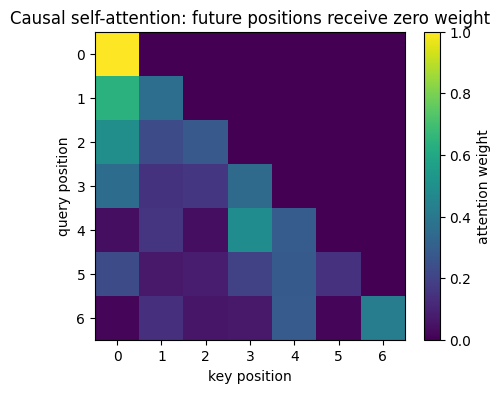

In [17]:
plt.figure(figsize=(5, 4))
plt.imshow(masked_attention, aspect="auto")
plt.colorbar(label="attention weight")
plt.xlabel("key position")
plt.ylabel("query position")
plt.title("Causal self-attention: future positions receive zero weight")
plt.show()

## 14. A tiny trainable next-token model

Now we train a minimal neural-style model from scratch.

For each previous token $i$, the model has a trainable logit row $Z_i \in R^d$.  The predicted distribution is

$$
p_\theta(\cdot \mid i) = \operatorname{softmax}(Z_i).
$$

For one training example with context $i$ and target $y$, the loss is

$$
L = -\log \operatorname{softmax}(Z_i)_y.
$$

The gradient with respect to the row $Z_i$ is

$$
\nabla_{Z_i} L = \operatorname{softmax}(Z_i) - e_y.
$$

This is exactly the same local gradient used in next-token prediction for large neural language models.  The difference is that real models compute logits from high-dimensional prefix representations.

In [18]:
# Prepare context-target index pairs for bigram next-token prediction.
train_pairs = []
for tokens in tokenized:
    for a, b in zip(tokens[:-1], tokens[1:]):
        train_pairs.append((idx[a], idx[b]))
train_pairs = np.array(train_pairs, dtype=int)

print("Number of next-token training examples:", len(train_pairs))
print("Example pair:", inv_vocab[train_pairs[0, 0]], "->", inv_vocab[train_pairs[0, 1]])

Number of next-token training examples: 106
Example pair: <bos> -> math


In [19]:
def row_softmax_matrix(Z):
    shifted = Z - np.max(Z, axis=1, keepdims=True)
    exps = np.exp(shifted)
    return exps / exps.sum(axis=1, keepdims=True)

def average_cross_entropy(Z, pairs):
    probs = row_softmax_matrix(Z)
    losses = [-math.log(max(probs[i, y], 1e-12)) for i, y in pairs]
    return float(np.mean(losses))

Z = rng.normal(scale=0.01, size=(V, V))
lr = 0.4
epochs = 350
loss_history = []

for epoch in range(epochs):
    # Shuffle for stochastic gradient descent.
    order = rng.permutation(len(train_pairs))
    for n in order:
        i, y = train_pairs[n]
        p = softmax(Z[i])
        grad = p.copy()
        grad[y] -= 1.0
        Z[i] -= lr * grad
    if epoch % 10 == 0 or epoch == epochs - 1:
        loss_history.append((epoch, average_cross_entropy(Z, train_pairs)))

loss_df = pd.DataFrame(loss_history, columns=["epoch", "average_cross_entropy"])
loss_df.tail()

,epoch,average_cross_entropy
31,310,0.820022
32,320,0.820128
33,330,0.819562
34,340,0.819356
35,349,0.819085


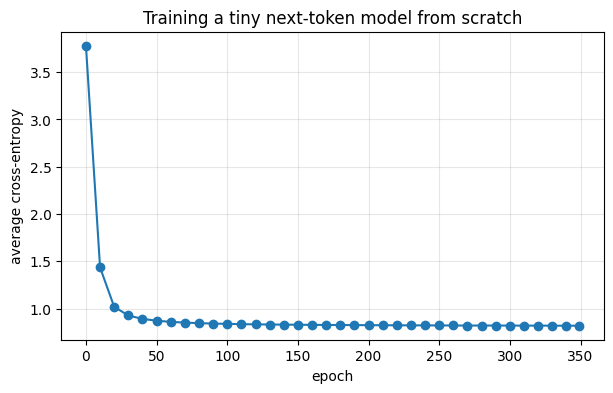

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(loss_df["epoch"], loss_df["average_cross_entropy"], marker="o")
plt.xlabel("epoch")
plt.ylabel("average cross-entropy")
plt.title("Training a tiny next-token model from scratch")
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
P_learned = row_softmax_matrix(Z)
context = "models"
comparison = pd.DataFrame({
    "token": vocab,
    "count_based_smoothed": P[idx[context]],
    "trained_softmax_model": P_learned[idx[context]],
})
comparison["absolute_difference"] = np.abs(comparison["count_based_smoothed"] - comparison["trained_softmax_model"])
comparison.sort_values("trained_softmax_model", ascending=False).head(12)

,token,count_based_smoothed,trained_softmax_model,absolute_difference
26,learn,0.075862,0.140346,0.064484
39,predict,0.075862,0.127626,0.051764
22,guide,0.075862,0.126117,0.050255
60,use,0.075862,0.125707,0.049845
30,map,0.075862,0.124959,0.049097
7,assign,0.075862,0.118561,0.042699
19,from,0.075862,0.116224,0.040362
1,<eos>,0.075862,0.113897,0.038035
17,explain,0.006897,0.000116,0.006780
41,prevent,0.006897,0.000116,0.006781


The trained table is a tiny version of next-token prediction.  In a Transformer, there is not just one logit row per previous token.  Instead, the model computes a contextual representation of the whole prefix and then maps it to next-token logits.

## 15. Exercises

### Exercise 1 — Chain rule

For the token sequence

```text
<bos> language models predict tokens <eos>
```

write the full autoregressive factorization.

### Exercise 2 — Perplexity by hand

A model assigns observed next-token probabilities

$$
0.50,\quad 0.25,\quad 0.40,\quad 0.10.
$$

Compute the log-probability, average NLL, and perplexity.

### Exercise 3 — Implement a trigram model

Modify the bigram model so that the context is the pair $(w_{t-2},w_{t-1})$.  Compare bigram and trigram perplexity on this tiny corpus.

### Exercise 4 — Decode under different temperatures

Generate 20 samples using temperatures $0.5$, $1.0$, and $2.0$.  For each temperature, compute average length and distinct-1.

### Exercise 5 — Top-$k$ versus top-$p$

Find a probability vector for which top-$k$ with $k=3$ and top-$p$ with $p=0.9$ keep different numbers of tokens.

### Exercise 6 — Beam width

Run beam search with beam widths $1$, $3$, $5$, and $10$.  Does the best sequence change?  What does this tell you about local versus global search?

### Exercise 7 — Neural model extension

Replace the trainable bigram logit table with a low-rank model

$$
Z = E F^T,
$$

where $E,F \in R^{d \times r}$.  Train it using gradient descent and compare performance for ranks $r=2,4,8$.

## 16. Mini-project: a mathematical decoding report

Choose a small corpus, such as course descriptions, textbook section titles, research abstracts, or advising FAQ text.  Build an autoregressive bigram or trigram language model and write a short report containing:

1. the vocabulary construction;
2. the estimated conditional probabilities;
3. the training average NLL and perplexity;
4. generated examples under greedy, temperature, top-$k$, top-$p$, and beam search decoding;
5. a comparison of diversity, repetition, and coherence;
6. a paragraph explaining how the same ideas scale to decoder-only Transformer language models.

The goal is not to build a strong generator.  The goal is to make next-token probability and decoding mathematically explicit.

## 17. What to remember

- Autoregressive language models estimate $p(w_t \mid w_{<t})$.
- Sequence probability becomes a product of next-token probabilities.
- Training commonly minimizes next-token cross-entropy using teacher forcing.
- Perplexity is $\exp(\text{average NLL})$.
- Generation is a recursive stochastic process.
- Temperature, top-$k$, and top-$p$ modify the next-token distribution before sampling.
- Beam search is approximate sequence search, not sampling.
- Causal masks prevent future-token leakage in decoder-only Transformers.